In [4]:
# - Setup comune

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
n = 220

df = pd.DataFrame({
    "altezza": rng.normal(170, 9.5, n),
    "peso": np.clip(rng.normal(70, 13, n), 45, 120),
    "gruppo": rng.choice(["A", "B", "C"], n, p=[0.35, 0.35, 0.30]),
})

df_bar = pd.DataFrame({"cat": ["A","B","C"], "val": [3,5,2]})


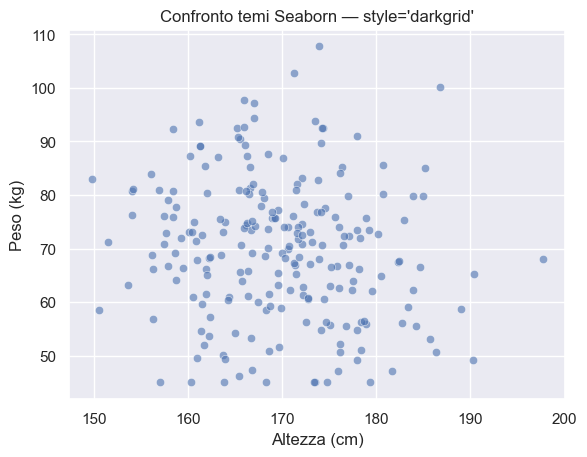

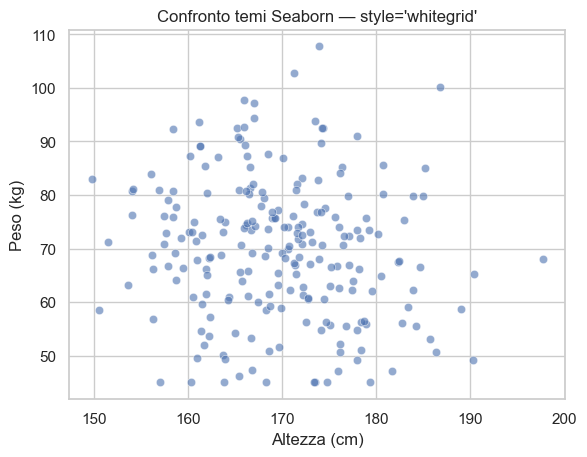

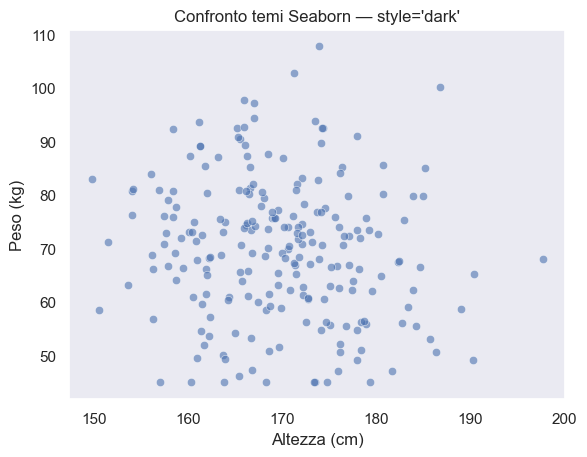

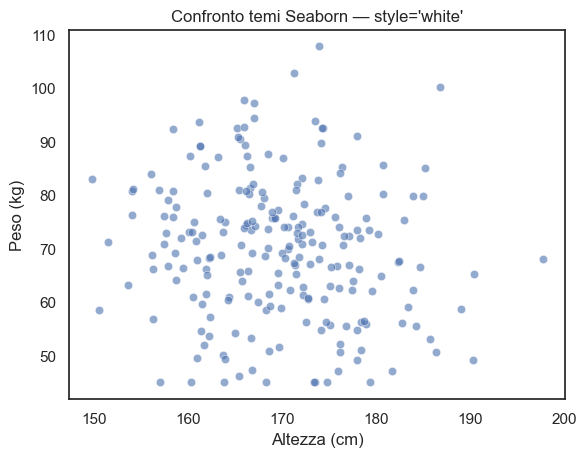

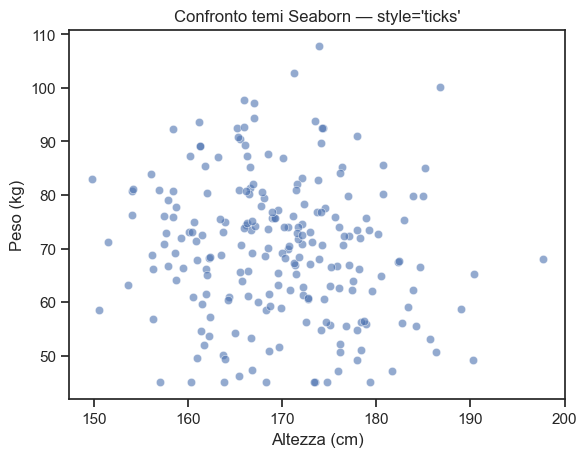

In [5]:
styles = ["darkgrid", "whitegrid", "dark", "white", "ticks"]

for st in styles:
    sns.set_theme(style=st)

    # Grafico identico per confronto “onesto”
    ax = sns.scatterplot(data=df, x="altezza", y="peso", alpha=0.6)
    ax.set_title(f"Confronto temi Seaborn — style='{st}'")
    ax.set_xlabel("Altezza (cm)")
    ax.set_ylabel("Peso (kg)")

    plt.show()

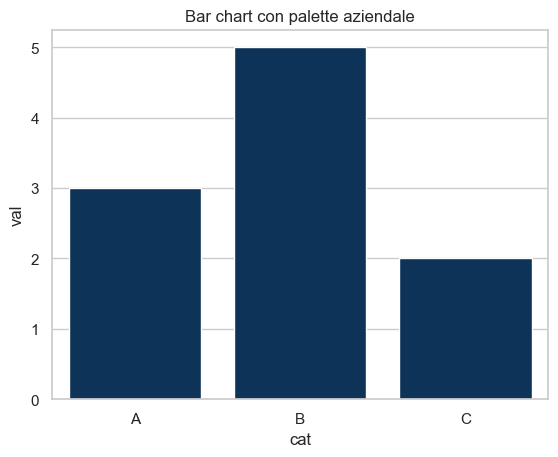

In [6]:
# - Esercizio 2 — palette personalizzata con 3 colori aziendali su un bar chart

palette = ["#003366", "#006699", "#0099cc"]  # 3 colori “brand”
sns.set_theme(style="whitegrid")
sns.set_palette(palette)

ax = sns.barplot(data=df_bar, x="cat", y="val")
ax.set_title("Bar chart con palette aziendale")
plt.show()

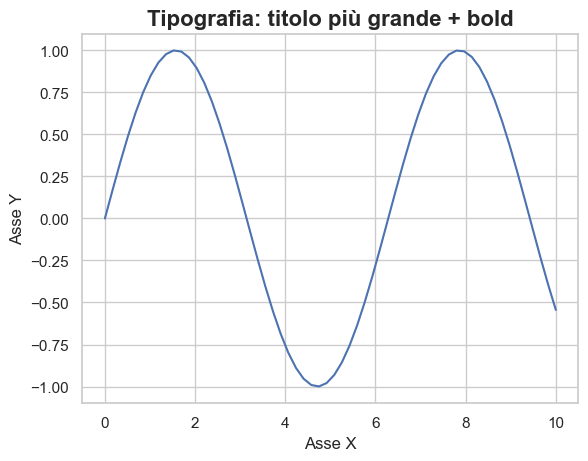

In [10]:
# - Esercizio 3 — font personalizzato + dimensioni/peso del testo

sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": "Arial",   # se non presente → fallback automatico
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
    }
)

ax = sns.lineplot(x=np.linspace(0, 10, 60), y=np.sin(np.linspace(0, 10, 60)))
ax.set_title("Tipografia: titolo più grande + bold")
ax.set_xlabel("Asse X")
ax.set_ylabel("Asse Y")
plt.show()


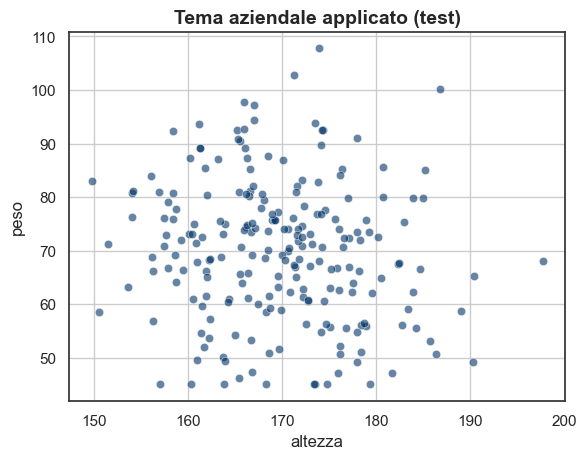

In [11]:
# - Esercizio 4 — funzione che imposti automaticamente stile, palette e font (tema riutilizzabile)

def set_corporate_theme():
    """
    Applica un tema aziendale coerente a tutti i grafici Seaborn/Matplotlib.
    Idea: lo chiami una volta a inizio notebook/script e non ci pensi più.
    """
    sns.set_theme(
        style="whitegrid",
        palette=["#003366", "#006699", "#0099cc", "#66cccc"],
        rc={
            "axes.facecolor": "white",
            "axes.edgecolor": "#333333",
            "grid.color": "#cccccc",
            "font.family": "Arial",
            "font.size": 12,
            "axes.titlesize": 14,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
        }
    )

# --- test rapido del tema
set_corporate_theme()

ax = sns.scatterplot(data=df, x="altezza", y="peso", alpha=0.6)
ax.set_title("Tema aziendale applicato (test)")
plt.show()

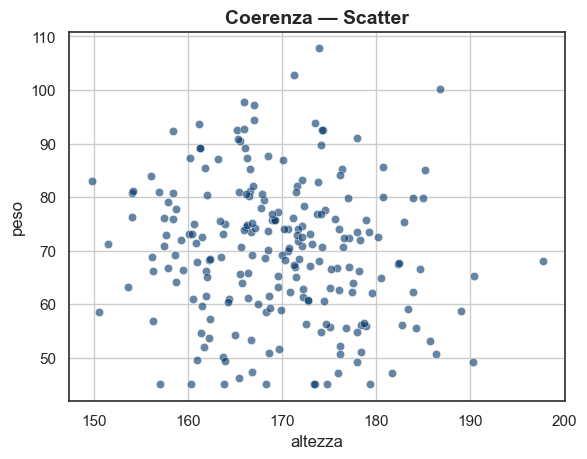

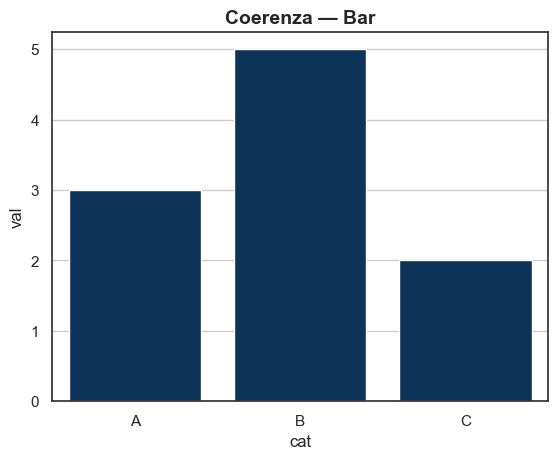

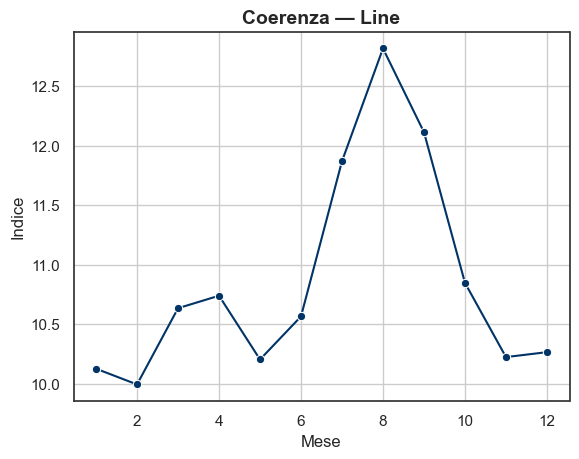

In [12]:
# - Esercizio 5 — applicare il tema aziendale a più grafici nello stesso notebook e verificare coerenza

set_corporate_theme()

# 1) Scatter
ax = sns.scatterplot(data=df, x="altezza", y="peso", alpha=0.6)
ax.set_title("Coerenza — Scatter")
plt.show()

# 2) Bar
ax = sns.barplot(data=df_bar, x="cat", y="val")
ax.set_title("Coerenza — Bar")
plt.show()

# 3) Line (esempio semplice)
x = np.arange(1, 13)
y = np.cumsum(np.random.default_rng(0).normal(0, 1, 12)) + 10
ax = sns.lineplot(x=x, y=y, marker="o")
ax.set_title("Coerenza — Line")
ax.set_xlabel("Mese")
ax.set_ylabel("Indice")
plt.show()